In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

states = [
    ((1, 2, 3), (), ()),
    ((2, 3), (1,), ()),
    ((3,), (1,), (2,)),
    ((1, 3), (), (2,)),
    ((1, 3), (2,), ()),
    ((3,), (2,), (1,)),
    ((3,), (1, 2), ()),
    ((2, 3), (), (1,)),
    ((), (1, 2), (3,)),
    ((1,), (2,), (3,)),
    ((), (2,), (1, 3)),
    ((2,), (), (1, 3)),
    ((2,), (1,), (3,)),
    ((), (1,), (2, 3)),
    ((1,), (), (2, 3)),
    ((1, 2), (), (3,)),
    ((1, 2), (3,), ()),
    ((2,), (3,), (1,)),
    ((), (2, 3), (1,)),
    ((1,), (2, 3), ()),
    ((), (1, 2, 3), ()),
    ((2,), (1, 3), ()),
    ((), (1, 3), (2,)),
    ((), (3,), (1, 2)),
    ((1,), (3,), (2,)),
    ((3,), (), (1, 2)),
    ((), (), (1, 2, 3)),
]

alpha = 0.7
gamma = 0.90
epsilon = 0.1
episodes = 500

Q = np.zeros((len(states), len(states)))

def possible_actions(state, prev_state):
    actions = []
    for i in range(3):
        if state[i]:  # Om det finns en eller flera ringar på peggen
            for j in range(3):
                # Om peg j är tom eller om den övre skivan på peg i är mindre än den undre skivan på peg j
                if i != j and (not state[j] or state[i][0] < state[j][0]):

                    # Kollar att den inte lägger till en action som leder till dens föregående state (undviker forever loops etc)
                    new_state = perform_action(state, (i, j))
                    if new_state != prev_state:
                        actions.append((i, j))
    return actions

def perform_action(state, action):
    # Gör en list of lists så det är lättare att manipulera värden
    state = [list(peg) for peg in state]

    # print(state)
    # print(action)


    disk = state[action[0]].pop(0)  # Tar bort ringen
    state[action[1]].insert(0, disk)  # Tillsätter ringen till nästa peg

    # Gör den tillbaka till rätta format
    new_state = tuple(tuple(peg) for peg in state)
    
    # print('New state: ',new_state)

    return new_state

steps_per_episode = []


prev_state = None
for i in range(episodes):
    state = states[0]
    steps = 0
    for j in range(100):
        actions = possible_actions(state, prev_state)  # Returnerar possible actions

        if np.random.rand() < epsilon:
            action = random.choice(actions)
        else:
            q_values = [Q[states.index(state), states.index(perform_action(state, a))] for a in actions]
            action = actions[np.argmax(q_values)]

        # Gör flyttningen och returnerar nya state
        new_state = perform_action(state, action)

        # Uppdaterar Q-value
        if new_state == states[-1]:
            Q[states.index(state), states.index(new_state)] = 0
        else:
            # Uppdatera Q-värdet baserat på belöningen och det maximala Q-värdet av nya state
            reward = -1
            next_actions = possible_actions(new_state, state)
            Q[states.index(state), states.index(new_state)] = (1 - alpha) * Q[states.index(state), states.index(new_state)] \
            + alpha * (reward + gamma * np.max([Q[states.index(new_state), states.index(perform_action(new_state, a))] for a in next_actions]))


        prev_state = state
        state = new_state

        steps += 1
        
        # Slutar episoden om den kommer i mål
        if state == states[-1]:
            break
    
    steps_per_episode.append(steps)
        
    epsilon *= 0.99

In [3]:
best_policy = []
def print_best_policy(Q, states):
    state = states[0]  # Början
    goal_state = states[-1]  # Målet

    print("Den bästa policyn:")
    i = 1
    while state != goal_state:
        actions = possible_actions(state, None)

        # Välj högsta Q-value för nuvarande state
        q_values = [Q[states.index(state), states.index(perform_action(state, a))] for a in actions]
        action = actions[np.argmax(q_values)]

        new_state = perform_action(state, action)

        print(f"{i}. {state} >> {new_state}")

        best_policy.append(new_state)

        state = new_state
        
        i += 1

print_best_policy(Q, states)

Den bästa policyn:
1. ((1, 2, 3), (), ()) >> ((2, 3), (), (1,))
2. ((2, 3), (), (1,)) >> ((3,), (2,), (1,))
3. ((3,), (2,), (1,)) >> ((3,), (1, 2), ())
4. ((3,), (1, 2), ()) >> ((), (1, 2), (3,))
5. ((), (1, 2), (3,)) >> ((1,), (2,), (3,))
6. ((1,), (2,), (3,)) >> ((1,), (), (2, 3))
7. ((1,), (), (2, 3)) >> ((), (), (1, 2, 3))


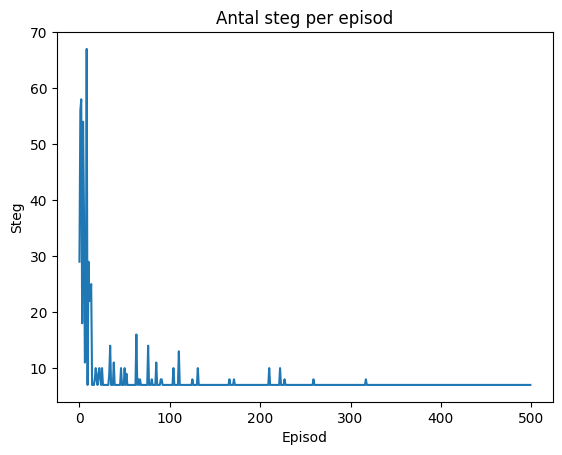

In [4]:
plt.plot(steps_per_episode)
plt.xlabel('Episod')
plt.ylabel('Steg')
plt.title('Antal steg per episod')
plt.show()

In [10]:
import pygame
import time

pygame.init()

WIDTH, HEIGHT = 800, 600
DISK_HEIGHT = 20
PEG_HEIGHT = 150
PEGS = [(WIDTH // 4, HEIGHT - PEG_HEIGHT), (WIDTH // 2, HEIGHT - PEG_HEIGHT), (3 * WIDTH // 4, HEIGHT - PEG_HEIGHT)]
COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

screen = pygame.display.set_mode((WIDTH, HEIGHT))

def draw_state(state):
    screen.fill((0, 0, 0))

    for x, y in PEGS:
        pygame.draw.rect(screen, (255, 255, 255), (x - 5, y, 10, PEG_HEIGHT))

    for i, peg in enumerate(state):
        for j, disk in enumerate(reversed(peg)):
            pygame.draw.rect(screen, COLORS[disk-1], (PEGS[i][0] - disk * 20, PEGS[i][1] + PEG_HEIGHT - (j+1) * DISK_HEIGHT, disk * 40, DISK_HEIGHT))
            
    pygame.display.flip()

state = ((1, 2, 3), (), ())
i = 0
running = True

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    draw_state(state)

    if i < len(best_policy):
        state = best_policy[i]
        i += 1

    time.sleep(2)

pygame.quit()